# Set up

In [1]:
pip install tensorflow

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
#Base library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
#Metrics
from sklearn.model_selection import GridSearchCV,train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score, PredictionErrorDisplay, mean_absolute_error, mean_squared_error, r2_score

In [5]:
#NN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

I0000 00:00:1779234669.613702     548 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779234669.664582     548 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779234670.743644     548 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
import xgboost as xgb

In [7]:
import os
import warnings
warnings.filterwarnings("ignore")

# Dataset

## Load and clean

In [8]:
data = pd.read_csv("spotify_dataset.csv").copy()

Duplicates come with different popularity score, first the df will be sorted by popularity and track id in order to drop the duplicates with the lower popularity score.

In [9]:
df_sorted = data.sort_values(by=['popularity', 'track_id'], ascending=[False, True], kind='mergesort')
df_cleaned = df_sorted.drop_duplicates(subset='track_id', keep='first')
df = df_cleaned.copy()

The objective is identify if the songs are hit, thus the tracks that are not of musical genre are discarded.

In [10]:
#Remove comedy, kids, children
df = df[df['track_genre'] != 'comedy']
df = df[df['track_genre'] != 'kids']
df = df[df['track_genre'] != 'children']
#Convert into numeric values
df['explicit'].replace({False: 0, True: 1}, inplace=True)

The columns to be discarded based on their relevance and literature recommendation (key). Track_genre is discarded since the genres may be not completely accurate.

In [11]:
drop_cols = [
    "Unnamed: 0",
    "track_id",
    "track_name",
    "album_name",
    "artists",
    'track_genre',
    'key'
]
feature_cols = [c for c in df.columns if c not in drop_cols]

df = df[feature_cols].copy()

In [12]:
#Identify numeric and categorical features
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical features: []


The objective is differenciate songs that are are hit or not, a song with popularity 0 can be considered a non-hit, however this task has to focused on a hit song and it has to learn more about positive characteristics, therefore all songs with popularity = 0 are discarded.

In [13]:
df = df[df['popularity'] > 0]

To establish song that can be considered as hit or not, it was set a threshold basen on the median, since the median is the value that is approximately at the middle of the data.

In [14]:
median = df['popularity'].median()
median

37.0

In [15]:
#Define is hit if the popularity is greater or equal than the median
df["is_hit"] = (df["popularity"] >= int(median)).astype(int)

To know the size of the df and the proportion of the classes

In [16]:
print(df.shape)
print(df["is_hit"].value_counts())
print(df["is_hit"].value_counts(normalize=True))
df.head()

(77580, 15)
is_hit
1    40181
0    37399
Name: count, dtype: int64
is_hit
1    0.51793
0    0.48207
Name: proportion, dtype: float64


,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,is_hit
20001,100,156943,0,0.714,0.472,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,1
51664,99,198937,0,0.621,0.782,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,1
20008,98,175238,1,0.561,0.965,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,1
67356,98,162637,0,0.835,0.679,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,1
67359,97,243716,0,0.650,0.715,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,1


From the above results, the accuracy to overcome is **0.51**

For this regression task, the aim is to know if a song is a hit, which would be its popularity, therefore, only the songs that are already labeled as hit will be held.

In [17]:
df = df[df['is_hit'] == 1]

In [18]:
#Define the variables to work on
y = df['popularity']
#Drop popularity because it is the target variable
df = df.drop(['popularity'], axis=1)
X = df.drop(columns=['is_hit'])

Redefine each type of columns

In [19]:
#Numeric
numeric_features = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
#Categorical
categorical_features = ['time_signature']
#Binary
binary_features = ['mode', 'explicit']

Preprocess the data by their type

In [20]:
#Preprocessor
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("bin", "passthrough")
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features)
])

## Split data

To avoid data leakage the flow will be:
1. Split the data.
2. Transform it using the preprocessor defined above.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(32144, 13) (8037, 13)
52.04831383773021 52.10078387458007


In [23]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [25]:
#To scaled
y_train_reg = y_train.values.reshape(-1, 1) if hasattr(y_train, 'values') else y_train.reshape(-1, 1)
y_test_reg = y_test.values.reshape(-1, 1) if hasattr(y_test, 'values') else y_test.reshape(-1, 1)

In [26]:
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train_reg)
y_test_scaled = scaler.transform(y_test_reg)

In [27]:
column_names = preprocessor.get_feature_names_out()

# Regression methods

Define a function to get the metrics for regression and plots

In [28]:
def reg_metrics(y_test, model, X_test):
    y_pred = model.predict(X_test)
    print("MAE (Mean Aboslute Error): ", round(mean_absolute_error(y_test, y_pred), 4))
    print("MSE (Mean Square Error): ", round(mean_squared_error(y_test, y_pred), 4))
    print("RMSE (Root Mean Square Error): ", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
    print("R2 Score: ", round(r2_score(y_test, y_pred), 4))
    
    print("\nMetrics plots:\n")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    #Actual vs predicted values
    PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind="actual_vs_predicted", 
        ax=axes[0], scatter_kwargs={"alpha": 0.5}
    )
    axes[0].set_title("Actual vs Predicted")
    
    #Residuals
    PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind="residual_vs_predicted", 
        ax=axes[1], scatter_kwargs={"alpha": 0.5}
    )
    axes[1].set_title("Residuals vs Predicted")
    
    #Histogram
    errors = y_test - y_pred
    axes[2].hist(errors, bins=30, edgecolor='black', alpha=0.7)
    axes[2].axvline(0, color='red', linestyle='--')
    axes[2].set_title("Distribution of Errors")
    axes[2].set_xlabel("Error (Actual - Predicted)")
    
    plt.tight_layout()
    plt.show()

In [55]:
def plot_training(history_model):
    plt.figure(figsize = (12,5))
    plt.subplot(121)
    plt.plot(history_model.history['loss'], label="train")
    plt.plot(history_model.history['val_loss'], label="validation")
    plt.title('MSE')
    plt.ylabel('Value')
    plt.xlabel('Epochs')
    plt.grid(True)
    plt.legend()
    plt.subplot(122)
    plt.plot(history_model.history['mae'], label="train")
    plt.plot(history_model.history['val_mae'], label="validation")
    plt.title('MAE')
    plt.ylabel('Value')
    plt.xlabel('Epochs')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

Define the size of the input for NN methods

In [30]:
n_cols = X_train_scaled.shape[1]

## Baseline Linear Regression

In [31]:
#Define LR and fit
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [32]:
#Metrics
lr_pred = lr.predict(X_test_scaled)
print(lr.score(X_test_scaled, y_test_scaled))

0.051140541064869205


## XGBoost
Tree based algorithms do not need scaled input

In [33]:
#Define parameters to try to use GridSearchCV 
params_grid = {
    'learning_rate': [0.01, 0.05],
    'gamma': [0, 0.01],
    'max_depth': [7, 8],
    'min_child_weight': [0, 1, 2],
    'subsample': [0.7, 0.8],
    'n_estimators': [300, 400, 600],
    'colsample_bytree': [0.8, 1],
    'random_state': [2000]    
}
regressor = xgb.XGBRegressor()
#USing MSE
grid_regressor = GridSearchCV(estimator=regressor, param_grid=params_grid, scoring='neg_mean_squared_error',cv=5, n_jobs=-1)

In [34]:
#Fit the grid search cv
grid_regressor.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1], 'gamma': [0, 0.01],
                         'learning_rate': [0.01, 0.05], 'max_depth': [7, 8],
                         'min_child_weight': [0, 1, 2],
                         'n_estimators': [300, 400, 600],
                         'random_state': [2000], 'subsample': [0.7, 0.8]},
             scoring='neg_mean_squared_error')

In [35]:
#Show the best parameters obtained
best_parameters = grid_regressor.best_params_
best_parameters

{'colsample_bytree': 1,
 'gamma': 0.01,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 0,
 'n_estimators': 600,
 'random_state': 2000,
 'subsample': 0.7}

In [36]:
best_xgb_model = grid_regressor.best_estimator_

MAE (Mean Aboslute Error):  8.3475
MSE (Mean Square Error):  107.2967
RMSE (Root Mean Square Error):  10.3584
R2 Score:  0.126

Metrics plots:



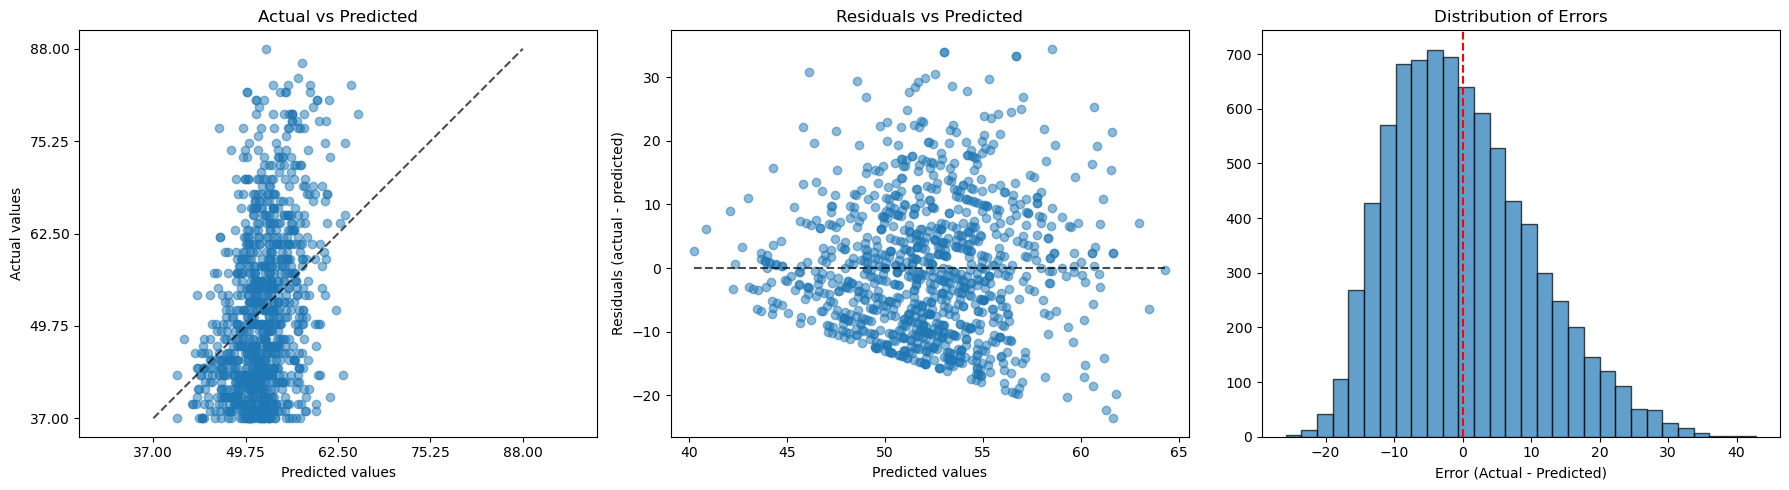

In [41]:
#Metrics
reg_metrics(y_test, best_xgb_model, X_test)

## MLP regressor

In [42]:
mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), 
                     activation='relu', 
                     solver='adam', 
                     alpha=0.001, 
                     batch_size=32,
                     learning_rate='constant', 
                     learning_rate_init=0.001, 
                     max_iter=100,
                     random_state=42, 
                     n_iter_no_change=10)

In [43]:
mlp.fit(X_train_scaled, y_train_scaled)

MLPRegressor(alpha=0.001, batch_size=32, hidden_layer_sizes=(128, 64, 32),
             max_iter=100, random_state=42)

In [46]:
y_pred_mlp = mlp.predict(X_test_scaled)

In [47]:
print("MAE (Mean Aboslute Error): ", round(mean_absolute_error(y_test_scaled, y_pred_mlp), 4))
print("MSE (Mean Square Error): ", round(mean_squared_error(y_test_scaled, y_pred_mlp), 4))
print("RMSE (Root Mean Square Error): ", round(np.sqrt(mean_squared_error(y_test_scaled, y_pred_mlp)), 4))
print("R2 Score: ", round(r2_score(y_test_scaled, y_pred_mlp), 4))

MAE (Mean Aboslute Error):  0.8247
MSE (Mean Square Error):  1.0961
RMSE (Root Mean Square Error):  1.0469
R2 Score:  -0.0599


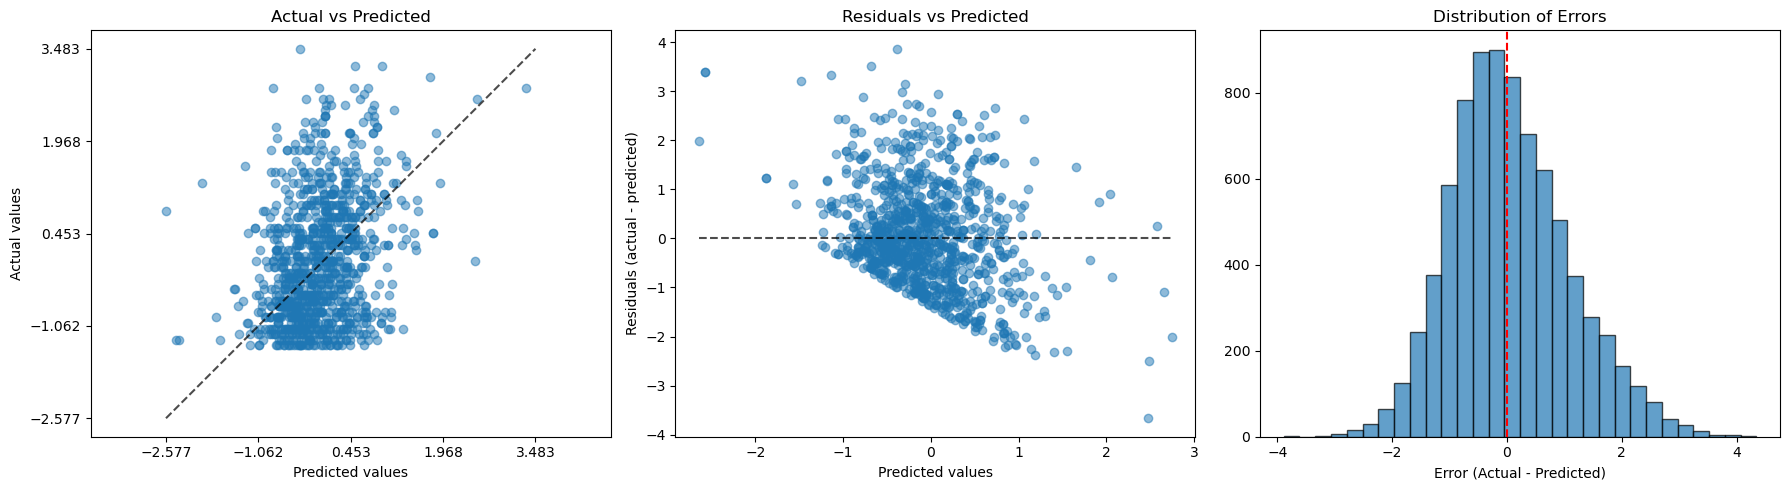

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_test_scaled, y_pred_mlp, kind="actual_vs_predicted", 
    ax=axes[0], scatter_kwargs={"alpha": 0.5}
)
axes[0].set_title("Actual vs Predicted")

#Residuals
PredictionErrorDisplay.from_predictions(
    y_test_scaled.flatten(), y_pred_mlp, kind="residual_vs_predicted", 
    ax=axes[1], scatter_kwargs={"alpha": 0.5}
)
axes[1].set_title("Residuals vs Predicted")

#Histogram
errors = y_test_scaled.flatten() - y_pred_mlp
axes[2].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title("Distribution of Errors")
axes[2].set_xlabel("Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

## Paper CNN model

https://arxiv.org/pdf/2505.07280 which also considers the WAV files of the songs

* First Convolutional Layer: This layer uses 16 filters with a kernel size of 3 × 3, stride of 1, and padding
to maintain the dimensionality, followed by a ReLU activation function to introduce non-linearity into the
model.
* Pooling Layer: Follows each convolutional block to reduce dimensionality and enhance the extraction of
dominant features, using a 2 × 2 window with a stride of 2.
* Subsequent Convolutional Layers: Increase in complexity and depth, using 32 and 64 filters, respectively,
to capture more detailed features from the audio spectrograms, each followed by ReLU for non-linearity.
* Final Convolutional Layer: Employs 128 filters, capturing the most abstract and representative features
from the input data.

In [50]:
paper = keras.Sequential([
    layers.Input(shape=(17,)),
    #1. First Layer: 16 with ReLU
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    #No pooling because we don't have audio files, changed for a dropout
    layers.Dropout(0.1),
    #2. Layers for depth
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1)    
])

E0000 00:00:1779235599.380625     548 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [51]:
paper.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [52]:
history_paper = paper.fit(
    X_train_scaled,  
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_test_scaled, y_test_scaled))

Epoch 1/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.0788 - mae: 0.8407 - val_loss: 0.9859 - val_mae: 0.8086
Epoch 2/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9738 - mae: 0.8008 - val_loss: 0.9746 - val_mae: 0.8017
Epoch 3/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9527 - mae: 0.7915 - val_loss: 0.9600 - val_mae: 0.7934
Epoch 4/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9440 - mae: 0.7890 - val_loss: 0.9697 - val_mae: 0.7958
Epoch 5/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9357 - mae: 0.7847 - val_loss: 0.9482 - val_mae: 0.7922
Epoch 6/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9312 - mae: 0.7836 - val_loss: 0.9478 - val_mae: 0.7932
Epoch 7/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9297 - mae: 0.7826 - val_loss: 0.9515 - val_mae: 0.7942
Epoch 8/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9235 - mae: 0.7796 - val_loss: 0.9444 - val_mae: 0.7842
Epoch 9/100
1005/1005 ━━━━━━━━━━

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
MAE (Mean Aboslute Error):  0.777
MSE (Mean Square Error):  0.9251
RMSE (Root Mean Square Error):  0.9618
R2 Score:  0.1054

Metrics plots:



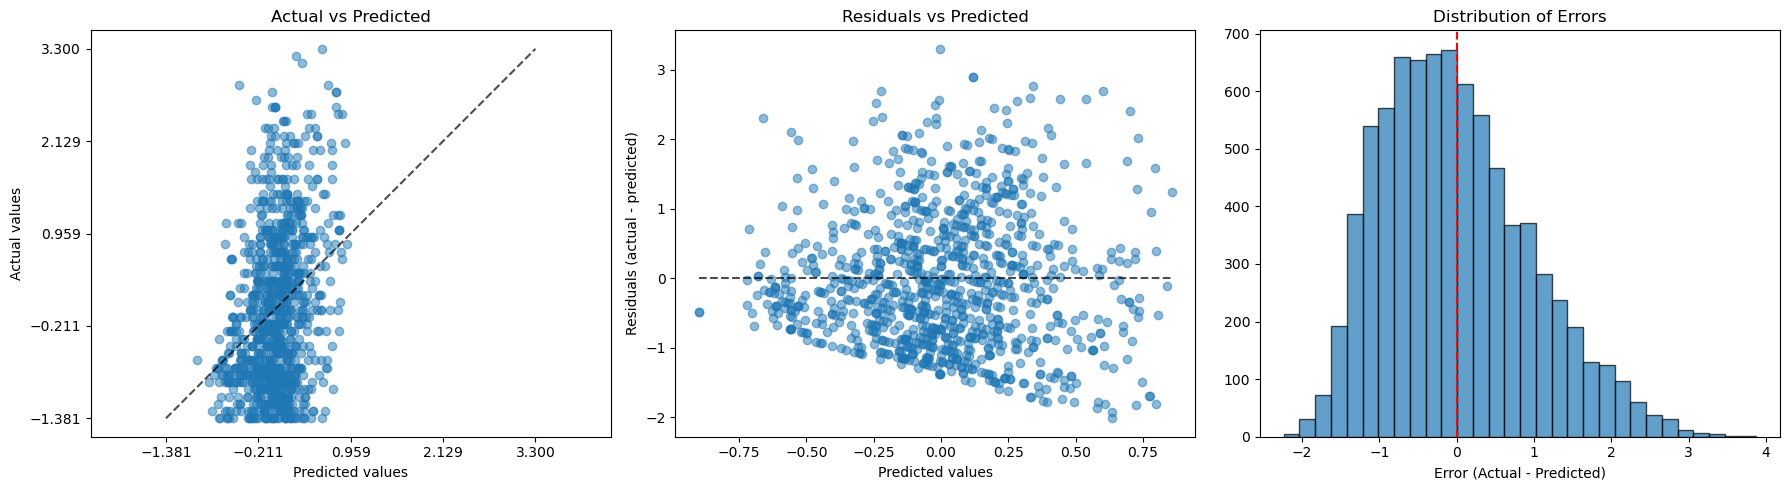

In [53]:
reg_metrics(y_test_scaled, paper, X_test_scaled)

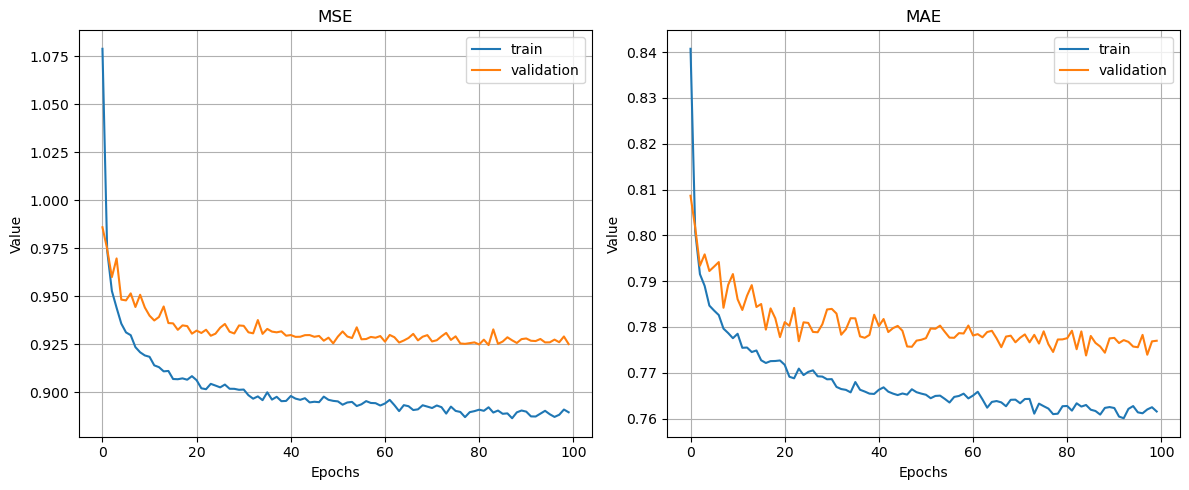

In [56]:
plot_training(history_paper)

## Simple NN

In [57]:
simple = keras.Sequential([
    layers.Input(shape=(17,)),        # Input layer
    layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
    layers.Dense(1)                  # Output layer with a single neuron (for regression)
])

In [58]:
simple.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [59]:
history_simple = simple.fit(
    X_train_scaled,  
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_test_scaled, y_test_scaled))

Epoch 1/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9614 - mae: 0.7971 - val_loss: 0.9568 - val_mae: 0.7930
Epoch 2/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9146 - mae: 0.7759 - val_loss: 0.9464 - val_mae: 0.7914
Epoch 3/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9080 - mae: 0.7727 - val_loss: 0.9425 - val_mae: 0.7898
Epoch 4/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9036 - mae: 0.7703 - val_loss: 0.9422 - val_mae: 0.7865
Epoch 5/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - loss: 0.8999 - mae: 0.7685 - val_loss: 0.9397 - val_mae: 0.7839
Epoch 6/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - loss: 0.8982 - mae: 0.7672 - val_loss: 0.9410 - val_mae: 0.7884
Epoch 7/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8963 - mae: 0.7666 - val_loss: 0.9362 - val_mae: 0.7830
Epoch 8/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8942 - mae: 0.7658 - val_loss: 0.9352 - val_mae: 0.7822
Epoch 9/100
1005/1005 ━━━━━━

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step
MAE (Mean Aboslute Error):  0.7825
MSE (Mean Square Error):  0.9304
RMSE (Root Mean Square Error):  0.9646
R2 Score:  0.1003

Metrics plots:



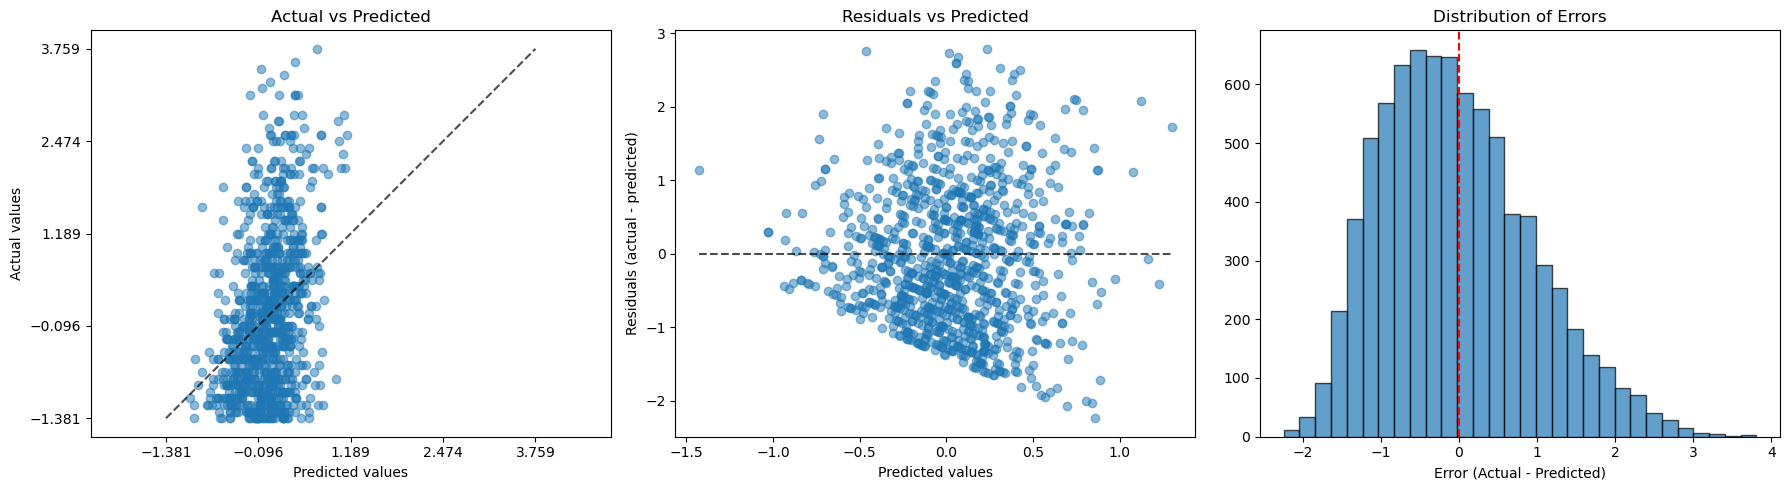

In [60]:
reg_metrics(y_test_scaled, simple, X_test_scaled)

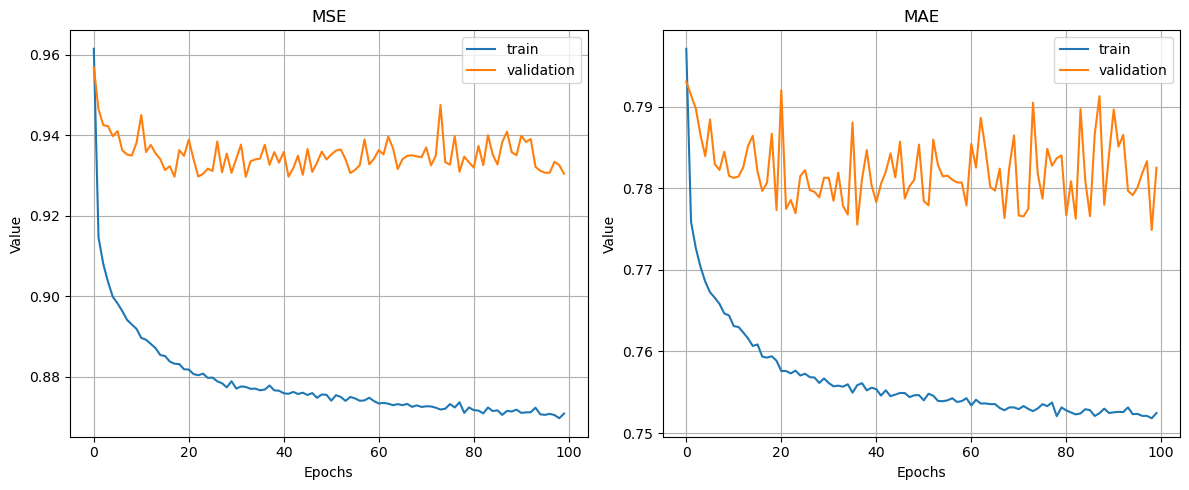

In [61]:
plot_training(history_simple)

## Hybrid model NN + RF

An hybrid model in which using NN features are extraceted and then the regression process is done by Random Forest was implemented, however this model is not supported in the institucional notebook, thus it was created and compiled in Google Colab. The results will be included. 
Based on the follwoing paper: https://www.sciencedirect.com/science/article/pii/S277267112400216X , modified after several trainings with different parameters and architectures.

## Regression models adding polynomial features
Create interaction of second degree between the variables

In [63]:
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

In [64]:
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

### Paper CNN model

In [65]:
paper_p = keras.Sequential([
    layers.Input(shape=(153,)),
    #1. First Layer: 16 with ReLU
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    #No pooling because we don't have audio files, changed for a dropout
    layers.Dropout(0.1),
    #2. Layers for depth
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1)    
])

In [66]:
paper_p.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [67]:
history_paper_p = paper_p.fit(
    X_train_poly,  
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_test_poly, y_test_scaled))

Epoch 1/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.1143 - mae: 0.8550 - val_loss: 1.0080 - val_mae: 0.8174
Epoch 2/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9793 - mae: 0.8049 - val_loss: 0.9914 - val_mae: 0.8177
Epoch 3/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9583 - mae: 0.7952 - val_loss: 0.9608 - val_mae: 0.7965
Epoch 4/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9392 - mae: 0.7863 - val_loss: 0.9555 - val_mae: 0.7952
Epoch 5/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9298 - mae: 0.7821 - val_loss: 0.9552 - val_mae: 0.7927
Epoch 6/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9243 - mae: 0.7788 - val_loss: 0.9470 - val_mae: 0.7915
Epoch 7/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9179 - mae: 0.7755 - val_loss: 0.9501 - val_mae: 0.7916
Epoch 8/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9114 - mae: 0.7728 - val_loss: 0.9459 - val_mae: 0.7869
Epoch 9/100
1005/1005 ━━━━━━━━━━

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step
MAE (Mean Aboslute Error):  0.7766
MSE (Mean Square Error):  0.9381
RMSE (Root Mean Square Error):  0.9685
R2 Score:  0.0929

Metrics plots:



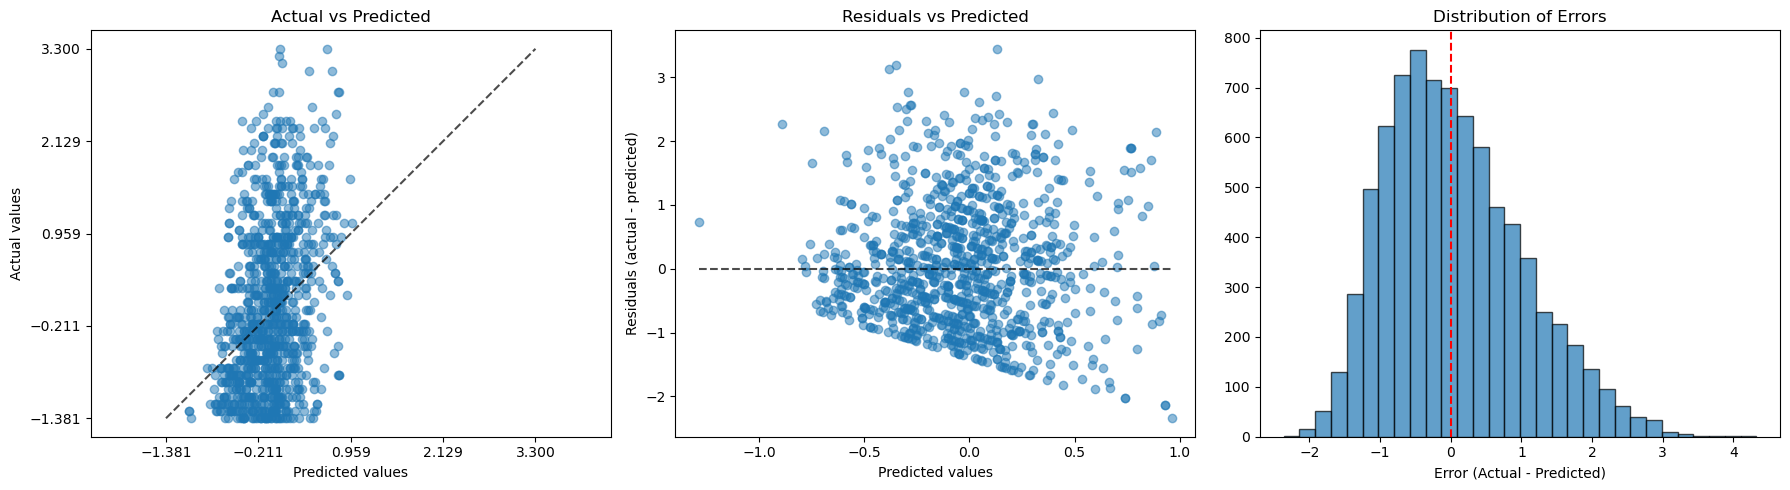

In [68]:
reg_metrics(y_test_scaled, paper_p, X_test_poly)

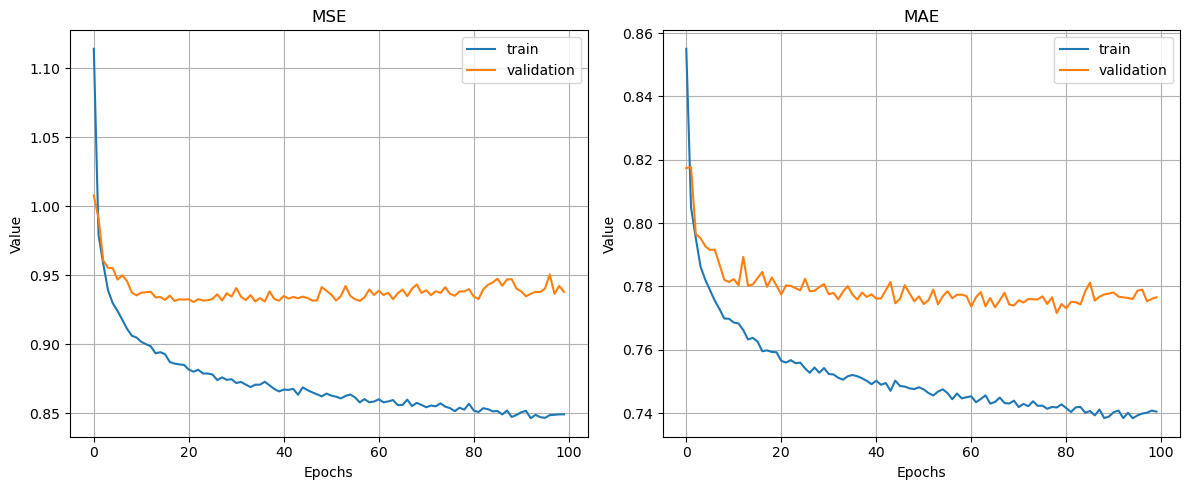

In [69]:
plot_training(history_paper_p)

### Simple NN

In [70]:
nn_p = keras.Sequential([
    layers.Input(shape=(153,)),        # Input layer
    layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
    layers.Dense(1)                  # Output layer with a single neuron (for regression)
])

In [71]:
nn_p.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [72]:
history_nn_p = nn_p.fit(
    X_train_poly,  
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_test_poly, y_test_scaled))

Epoch 1/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9790 - mae: 0.7990 - val_loss: 0.9565 - val_mae: 0.7947
Epoch 2/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9064 - mae: 0.7696 - val_loss: 0.9433 - val_mae: 0.7891
Epoch 3/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8953 - mae: 0.7632 - val_loss: 0.9356 - val_mae: 0.7850
Epoch 4/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8872 - mae: 0.7602 - val_loss: 0.9402 - val_mae: 0.7889
Epoch 5/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8832 - mae: 0.7579 - val_loss: 0.9350 - val_mae: 0.7810
Epoch 6/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - loss: 0.8806 - mae: 0.7565 - val_loss: 0.9356 - val_mae: 0.7767
Epoch 7/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8780 - mae: 0.7540 - val_loss: 0.9365 - val_mae: 0.7869
Epoch 8/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - loss: 0.8722 - mae: 0.7522 - val_loss: 0.9552 - val_mae: 0.7939
Epoch 9/100
1005/1005 ━━━━━━

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step
MAE (Mean Aboslute Error):  0.7766
MSE (Mean Square Error):  0.9381
RMSE (Root Mean Square Error):  0.9685
R2 Score:  0.0929

Metrics plots:



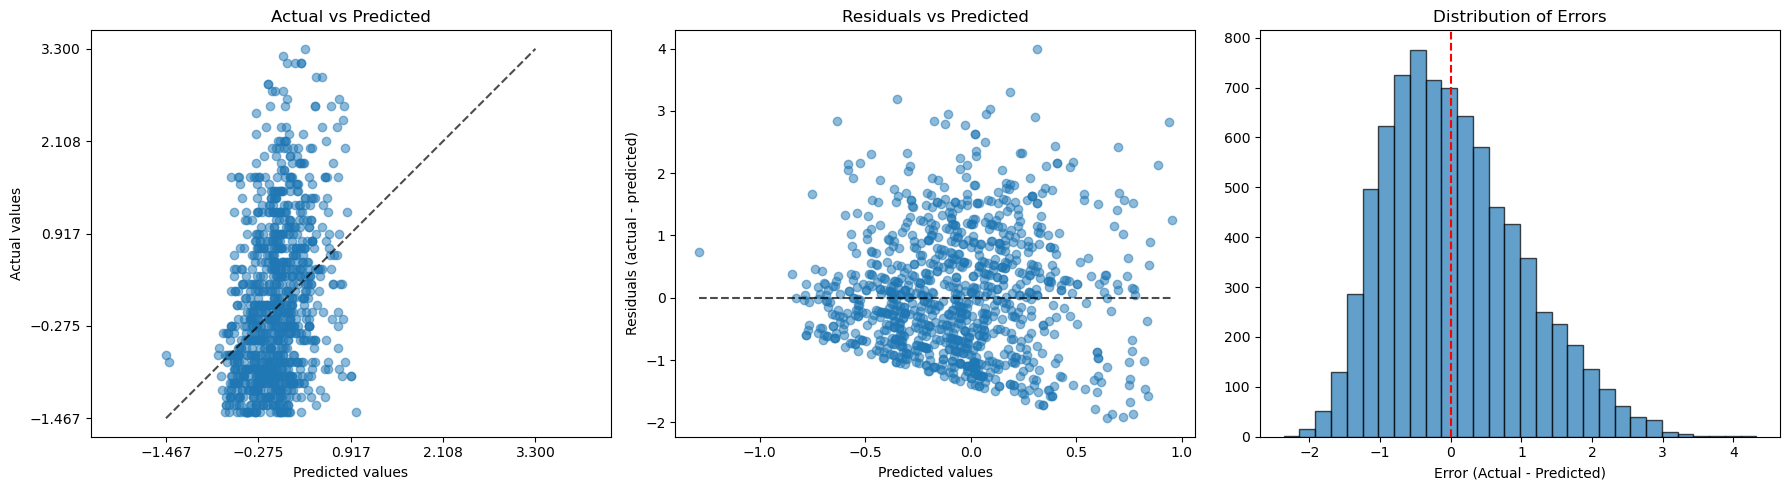

In [73]:
reg_metrics(y_test_scaled, paper_p, X_test_poly)

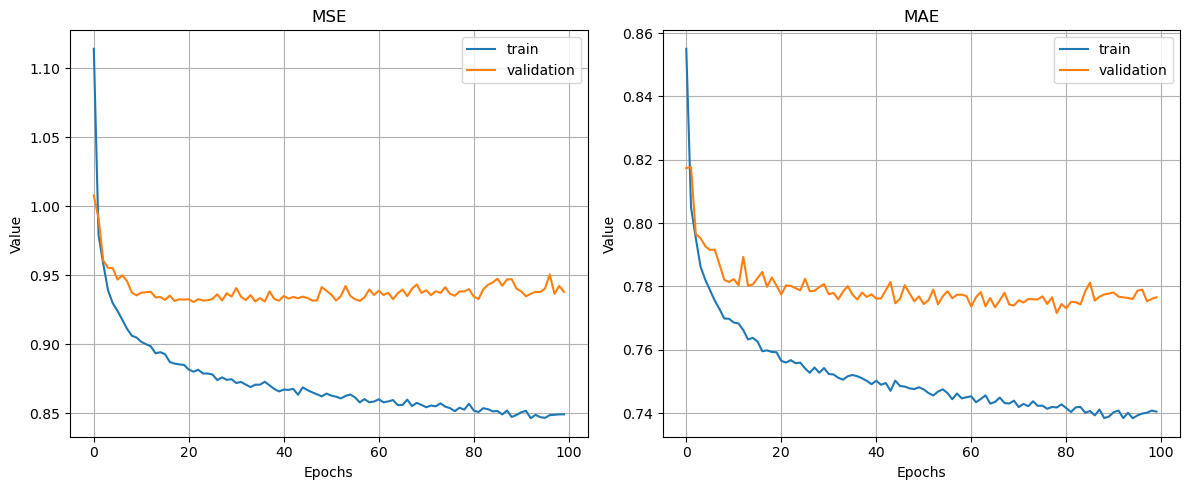

In [74]:
plot_training(history_paper_p)

# Comparison between models

Define fucntion to get metrics, here will be used RMSE, to know how much the models are failing and R² how much the model is capable to explain.

In [75]:
def evaluation(y_test, model, X_test):
    y_pred = model.predict(X_test)

    r2 = round(r2_score(y_test, y_pred), 4)
    rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    
    return r2, rmse

In [76]:
r2_lr, rmse_lr = round(lr.score(X_test_scaled, y_test_scaled),4), round(np.sqrt(mean_squared_error(y_test, lr_pred)), 4)

In [77]:
r2_xgb, rmse_xgb = evaluation(y_test, best_xgb_model, X_test)
r2_mlp, rmse_mlp = evaluation(y_test_scaled, mlp, X_test_scaled)
r2_paper, rmse_paper = evaluation(y_test_scaled, paper, X_test_scaled)
r2_simple, rmse_simple = evaluation(y_test_scaled, simple, X_test_scaled)
r2_paper_p, rmse_paper_p = evaluation(y_test_scaled, paper_p, X_test_poly)
r2_nn_p, rmse_nn_p = evaluation(y_test_scaled, nn_p, X_test_poly)

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step


In [78]:
#Obtained results for the hybrid model
r2_hybrid, rmse_hybrid = 0.1208, 10.3889

In [79]:
comp = {'Model': ['Baseline (LR)', 'XGBoost', 'MLP regressor', 'CNN Paper', 'Simple NN', 'Paper poly', 'Simple poly', 'Hybrid NN + RF'], 
        'R²': [r2_lr, r2_xgb, r2_mlp, r2_paper, r2_simple, r2_paper_p, r2_nn_p, r2_hybrid],
        'RMSE': [rmse_lr, rmse_xgb, rmse_mlp, rmse_paper, rmse_simple, rmse_paper_p, rmse_nn_p, rmse_hybrid]
       }

In [80]:
df_comp = pd.DataFrame(data=comp)
df_comp.sort_values('R²', ascending = False)

,Model,R²,RMSE
1,XGBoost,0.1260,10.3584
7,Hybrid NN + RF,0.1208,10.3889
3,CNN Paper,0.1054,0.9618
4,Simple NN,0.1003,0.9646
5,Paper poly,0.0929,0.9685
6,Simple poly,0.0586,0.9867
0,Baseline (LR),0.0511,53.2580
2,MLP regressor,-0.0599,1.0469
